[문제] 파이토치가 제공하는 Mnist데이터셋을 로드하여 분류하는 모델을 만들어 마지막에 정확도를 출력하는 코드를 완성하시오.

제출형식 : 홍길동_0527_PyTorch_Mnist_정확도.ipynb

<처리조건>
1. 데이터 로드는 아래와 같다.

from torchvision.datasets import MNIST

train_data = MNIST(root=".",  train=True,  download=True)
test_data = MNIST(root=".",  train=False,  download=True)

2. 성능을 최적화 할수 있는 모델을 설계한다.
3. 마지막에 테스트 데이터에 대한 정확도를 구해서 출력한다.

In [1]:
import torch

torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.backends.cudnn.deterministic = True

In [2]:
from torchvision.datasets import MNIST

train_data = MNIST(root=".",  train=True,  download=True)
test_data = MNIST(root=".",  train=False,  download=True)

In [3]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: .
    Split: Train

In [4]:
print(train_data.data.shape, test_data.data.shape)
print(train_data.targets.shape, test_data.targets.shape)

torch.Size([60000, 28, 28]) torch.Size([10000, 28, 28])
torch.Size([60000]) torch.Size([10000])


In [5]:
train_input = train_data.data
train_target = train_data.targets
train_scaled = train_input.reshape(-1,1,28,28) / 255.0

In [6]:
from sklearn.model_selection import train_test_split

train_scaled, val_scaled, train_target, val_target = train_test_split(train_scaled, train_target, test_size=0.2, random_state=42)

In [7]:
import torch.nn as nn

model = nn.Sequential()
model.add_module('conv1', nn.Conv2d(1,32, kernel_size=3, padding='same'))
model.add_module('relu1', nn.ReLU())
model.add_module('pool1', nn.MaxPool2d(2))
model.add_module('conv2', nn.Conv2d(32, 64, kernel_size=3, padding='same'))
model.add_module('relu2', nn.ReLU())
model.add_module('pool2', nn.MaxPool2d(2))
model.add_module('flatten', nn.Flatten()) # 입력층
model.add_module('dense1', nn.Linear(3136,100)) # 은닉층
model.add_module('relu3', nn.ReLU())
model.add_module('dropout', nn.Dropout(0.3))
model.add_module('dense2', nn.Linear(100,10)) # 출력층

In [8]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)
model.to(device) # GPU에서 실행 되도록 한다.

device = cuda


Sequential(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dense1): Linear(in_features=3136, out_features=100, bias=True)
  (relu3): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (dense2): Linear(in_features=100, out_features=10, bias=True)
)

In [9]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss() # 다중 분류, 이진분류: nn.BCELoss 또는 nn.BCEWithLogitsLoss
optimizer = optim.Adam(model.parameters())

In [10]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(train_scaled, train_target)
val_dataset = TensorDataset(val_scaled, val_target)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [11]:
train_hist = [] # 훈련 손실 저장
val_hist = [] # 검증 손실 저장
patience = 3 # 검증 손실이 향상될 때까지 에포크 횟수 설정
best_loss = -1 # 최상의 손실 저장
early_stopping_counter = 0 # 연속적으로 검증 손실이 향상되지 않은 에포크 횟수 저장

epochs = 20
for epoch in range(epochs): # 에포크 반복(학습)
    model.train() # 학습(훈련)
    train_loss = 0 # 손실값 초기화
    for inputs, targets in train_loader: # 1 epoch 실행
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad() # 이전에 계산된 기울기값 초기화하는 함수
        outputs = model(inputs) # 모델에 입력 데이터 전달
        loss = criterion(outputs, targets) # 손실값 계산
        loss.backward() # 각 층의 모델 파라메터에 대한 기울기(그레디언트)를 계산
        optimizer.step() # 손실 파라메터 업데이트 
        train_loss += loss.item()
    
    model.eval() # PyTorch에서 모델을 검증(Validation) 및 추론(Inference) 모드로 전환하는 메서드
    val_loss = 0
    with torch.no_grad(): # PyTorch에서 자동 미분(Autograd) 엔진을 비활성화, Gradient)를 계산하지 않음
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

    train_loss = train_loss / len(train_loader)
    val_loss = val_loss / len(val_loader)
    train_hist.append(train_loss)
    val_hist.append(val_loss)
    print(f"에포크:{epoch+1},", f"훈련 손실:{train_loss:.4f}, 검증 손실:{val_loss:.4f}")

    if best_loss == -1 or val_loss < best_loss:
        best_loss = val_loss
        early_stopping_counter = 0
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= patience:
            print(f"{epoch+1}번째 에포크에서 조기 종료되었습니다.")
            break

에포크:1, 훈련 손실:0.2342, 검증 손실:0.0601
에포크:2, 훈련 손실:0.0764, 검증 손실:0.0515
에포크:3, 훈련 손실:0.0574, 검증 손실:0.0410
에포크:4, 훈련 손실:0.0450, 검증 손실:0.0384
에포크:5, 훈련 손실:0.0371, 검증 손실:0.0407
에포크:6, 훈련 손실:0.0321, 검증 손실:0.0389
에포크:7, 훈련 손실:0.0254, 검증 손실:0.0366
에포크:8, 훈련 손실:0.0240, 검증 손실:0.0378
에포크:9, 훈련 손실:0.0202, 검증 손실:0.0411
에포크:10, 훈련 손실:0.0183, 검증 손실:0.0468
10번째 에포크에서 조기 종료되었습니다.


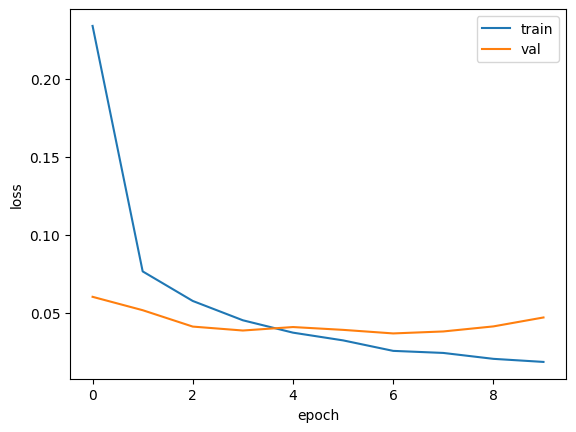

In [12]:
import matplotlib.pyplot as plt

plt.plot(train_hist, label='train')
plt.plot(val_hist, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [13]:
model.load_state_dict(torch.load('best_model.pt', weights_only=True)) # 모델 로드

<All keys matched successfully>

In [14]:
test_scaled = test_data.data.reshape(-1,1,28,28) / 255.0
test_target = test_data.targets

In [15]:
test_dataset = TensorDataset(test_scaled, test_target)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [16]:
model.eval() # PyTorch에서 모델을 검증(Validation) 및 추론(Inference) 모드로 전환하는 메서드
corrects = 0
with torch.no_grad(): # PyTorch에서 자동 미분(Autograd) 엔진을 비활성화, Gradient)를 계산하지 않음
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        predicts = torch.argmax(outputs, 1)
        corrects += (predicts == targets).sum().item() # 일치하는 데이터 카운트

accuracy = corrects / len(test_dataset) # 정확도 계산
print(f"검증 정확도: {accuracy:.4f}")

검증 정확도: 0.9910


In [17]:
import torch.nn as nn

model = nn.Sequential()
model.add_module('conv1', nn.Conv2d(1,32, kernel_size=3, padding='same'))
model.add_module('relu1', nn.ReLU())
model.add_module('pool1', nn.MaxPool2d(2))
model.add_module('conv2', nn.Conv2d(32, 64, kernel_size=3, padding='same'))
model.add_module('relu2', nn.ReLU())
model.add_module('pool2', nn.MaxPool2d(2))
model.add_module('flatten', nn.Flatten()) # 입력층
model.add_module('dense1', nn.Linear(3136,100)) # 은닉층
model.add_module('relu3', nn.ReLU())
model.add_module('dropout', nn.Dropout(0.3))
model.add_module('dense2', nn.Linear(100,10)) # 출력층

In [19]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)
model.to(device) # GPU에서 실행 되도록 한다.

device = cuda


Sequential(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dense1): Linear(in_features=3136, out_features=100, bias=True)
  (relu3): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (dense2): Linear(in_features=100, out_features=10, bias=True)
)

In [24]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss() # 다중 분류, 이진분류: nn.BCELoss 또는 nn.BCEWithLogitsLoss
optimizer = optim.Adam(model.parameters())

In [25]:
train_hist = [] # 훈련 손실 저장
val_hist = [] # 검증 손실 저장
patience = 2 # 검증 손실이 향상될 때까지 에포크 횟수 설정
best_loss = -1 # 최상의 손실 저장
early_stopping_counter = 0 # 연속적으로 검증 손실이 향상되지 않은 에포크 횟수 저장

epochs = 20
for epoch in range(epochs): # 에포크 반복(학습)
    model.train() # 학습(훈련)
    train_loss = 0 # 손실값 초기화
    for inputs, targets in train_loader: # 1 epoch 실행
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad() # 이전에 계산된 기울기값 초기화하는 함수
        outputs = model(inputs) # 모델에 입력 데이터 전달
        loss = criterion(outputs, targets) # 손실값 계산
        loss.backward() # 각 층의 모델 파라메터에 대한 기울기(그레디언트)를 계산
        optimizer.step() # 손실 파라메터 업데이트 
        train_loss += loss.item()
    
    model.eval() # PyTorch에서 모델을 검증(Validation) 및 추론(Inference) 모드로 전환하는 메서드
    val_loss = 0
    with torch.no_grad(): # PyTorch에서 자동 미분(Autograd) 엔진을 비활성화, Gradient)를 계산하지 않음
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

    train_loss = train_loss / len(train_loader)
    val_loss = val_loss / len(val_loader)
    train_hist.append(train_loss)
    val_hist.append(val_loss)
    print(f"에포크:{epoch+1},", f"훈련 손실:{train_loss:.4f}, 검증 손실:{val_loss:.4f}")

    if best_loss == -1 or val_loss < best_loss:
        best_loss = val_loss
        early_stopping_counter = 0
        torch.save(model.state_dict(), 'best_model2.pt')
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= patience:
            print(f"{epoch+1}번째 에포크에서 조기 종료되었습니다.")
            break

에포크:1, 훈련 손실:0.2179, 검증 손실:0.0563
에포크:2, 훈련 손실:0.0794, 검증 손실:0.0418
에포크:3, 훈련 손실:0.0595, 검증 손실:0.0359
에포크:4, 훈련 손실:0.0466, 검증 손실:0.0384
에포크:5, 훈련 손실:0.0397, 검증 손실:0.0395
5번째 에포크에서 조기 종료되었습니다.


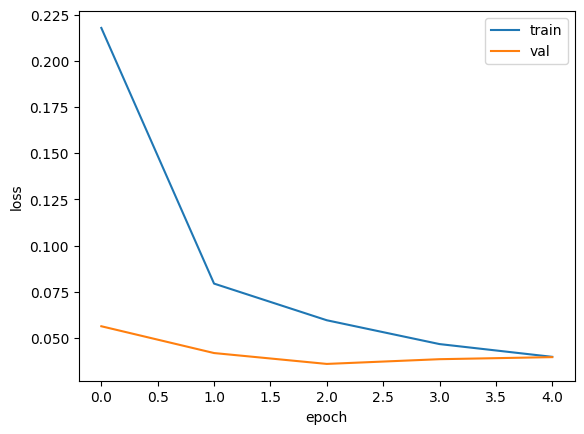

In [26]:
import matplotlib.pyplot as plt

plt.plot(train_hist, label='train')
plt.plot(val_hist, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [27]:
model.load_state_dict(torch.load('best_model2.pt', weights_only=True)) # 모델 로드

<All keys matched successfully>

In [28]:
model.eval() # PyTorch에서 모델을 검증(Validation) 및 추론(Inference) 모드로 전환하는 메서드
corrects = 0
with torch.no_grad(): # PyTorch에서 자동 미분(Autograd) 엔진을 비활성화, Gradient)를 계산하지 않음
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        predicts = torch.argmax(outputs, 1)
        corrects += (predicts == targets).sum().item() # 일치하는 데이터 카운트

accuracy = corrects / len(test_dataset) # 정확도 계산
print(f"검증 정확도: {accuracy:.4f}")

검증 정확도: 0.9898


In [30]:
import torch.nn as nn

model = nn.Sequential()
model.add_module('conv1', nn.Conv2d(1,64, kernel_size=3, padding='same'))
model.add_module('relu1', nn.ReLU())
model.add_module('pool1', nn.MaxPool2d(2))
model.add_module('conv2', nn.Conv2d(64, 64, kernel_size=3, padding='same'))
model.add_module('relu2', nn.ReLU())
model.add_module('pool2', nn.MaxPool2d(2))
model.add_module('flatten', nn.Flatten()) # 입력층
model.add_module('dense1', nn.Linear(3136,100)) # 은닉층
model.add_module('relu3', nn.ReLU())
model.add_module('dropout', nn.Dropout(0.3))
model.add_module('dense2', nn.Linear(100,10)) # 출력층

In [31]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)
model.to(device) # GPU에서 실행 되도록 한다.

device = cuda


Sequential(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dense1): Linear(in_features=3136, out_features=100, bias=True)
  (relu3): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (dense2): Linear(in_features=100, out_features=10, bias=True)
)

In [32]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss() # 다중 분류, 이진분류: nn.BCELoss 또는 nn.BCEWithLogitsLoss
optimizer = optim.Adam(model.parameters())

In [33]:
train_hist = [] # 훈련 손실 저장
val_hist = [] # 검증 손실 저장
patience = 2 # 검증 손실이 향상될 때까지 에포크 횟수 설정
best_loss = -1 # 최상의 손실 저장
early_stopping_counter = 0 # 연속적으로 검증 손실이 향상되지 않은 에포크 횟수 저장

epochs = 20
for epoch in range(epochs): # 에포크 반복(학습)
    model.train() # 학습(훈련)
    train_loss = 0 # 손실값 초기화
    for inputs, targets in train_loader: # 1 epoch 실행
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad() # 이전에 계산된 기울기값 초기화하는 함수
        outputs = model(inputs) # 모델에 입력 데이터 전달
        loss = criterion(outputs, targets) # 손실값 계산
        loss.backward() # 각 층의 모델 파라메터에 대한 기울기(그레디언트)를 계산
        optimizer.step() # 손실 파라메터 업데이트 
        train_loss += loss.item()
    
    model.eval() # PyTorch에서 모델을 검증(Validation) 및 추론(Inference) 모드로 전환하는 메서드
    val_loss = 0
    with torch.no_grad(): # PyTorch에서 자동 미분(Autograd) 엔진을 비활성화, Gradient)를 계산하지 않음
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

    train_loss = train_loss / len(train_loader)
    val_loss = val_loss / len(val_loader)
    train_hist.append(train_loss)
    val_hist.append(val_loss)
    print(f"에포크:{epoch+1},", f"훈련 손실:{train_loss:.4f}, 검증 손실:{val_loss:.4f}")

    if best_loss == -1 or val_loss < best_loss:
        best_loss = val_loss
        early_stopping_counter = 0
        torch.save(model.state_dict(), 'best_model2.pt')
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= patience:
            print(f"{epoch+1}번째 에포크에서 조기 종료되었습니다.")
            break

에포크:1, 훈련 손실:0.1912, 검증 손실:0.0700
에포크:2, 훈련 손실:0.0684, 검증 손실:0.0429
에포크:3, 훈련 손실:0.0488, 검증 손실:0.0364
에포크:4, 훈련 손실:0.0402, 검증 손실:0.0328
에포크:5, 훈련 손실:0.0314, 검증 손실:0.0364
에포크:6, 훈련 손실:0.0276, 검증 손실:0.0379
6번째 에포크에서 조기 종료되었습니다.


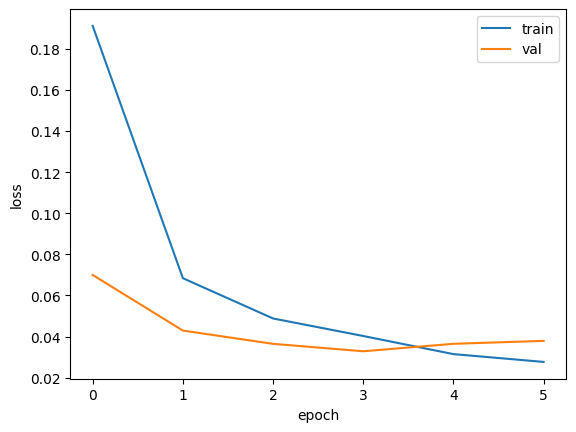

In [34]:
import matplotlib.pyplot as plt

plt.plot(train_hist, label='train')
plt.plot(val_hist, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [35]:
model.load_state_dict(torch.load('best_model2.pt', weights_only=True)) # 모델 로드

<All keys matched successfully>

In [36]:
model.eval() # PyTorch에서 모델을 검증(Validation) 및 추론(Inference) 모드로 전환하는 메서드
corrects = 0
with torch.no_grad(): # PyTorch에서 자동 미분(Autograd) 엔진을 비활성화, Gradient)를 계산하지 않음
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        predicts = torch.argmax(outputs, 1)
        corrects += (predicts == targets).sum().item() # 일치하는 데이터 카운트

accuracy = corrects / len(test_dataset) # 정확도 계산
print(f"검증 정확도: {accuracy:.4f}")

검증 정확도: 0.9921


In [100]:
import torch.nn as nn

model = nn.Sequential()
model.add_module('conv1', nn.Conv2d(1,64, kernel_size=3, padding='same'))
model.add_module('relu1', nn.ReLU())
model.add_module('pool1', nn.MaxPool2d(2))
model.add_module('conv2', nn.Conv2d(64, 128, kernel_size=3, padding='same'))
model.add_module('relu2', nn.ReLU())
model.add_module('pool2', nn.MaxPool2d(2))
model.add_module('flatten', nn.Flatten()) # 입력층
model.add_module('dense1', nn.Linear(6272,100)) # 은닉층
model.add_module('relu3', nn.ReLU())
model.add_module('dropout', nn.Dropout(0.3))
model.add_module('dense2', nn.Linear(100,10)) # 출력층

In [101]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)
model.to(device) # GPU에서 실행 되도록 한다.

device = cuda


Sequential(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dense1): Linear(in_features=6272, out_features=100, bias=True)
  (relu3): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (dense2): Linear(in_features=100, out_features=10, bias=True)
)

In [102]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss() # 다중 분류, 이진분류: nn.BCELoss 또는 nn.BCEWithLogitsLoss
optimizer = optim.Adam(model.parameters())

In [103]:
train_hist = [] # 훈련 손실 저장
val_hist = [] # 검증 손실 저장
patience = 3 # 검증 손실이 향상될 때까지 에포크 횟수 설정
best_loss = -1 # 최상의 손실 저장
early_stopping_counter = 0 # 연속적으로 검증 손실이 향상되지 않은 에포크 횟수 저장

epochs = 20
for epoch in range(epochs): # 에포크 반복(학습)
    model.train() # 학습(훈련)
    train_loss = 0 # 손실값 초기화
    for inputs, targets in train_loader: # 1 epoch 실행
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad() # 이전에 계산된 기울기값 초기화하는 함수
        outputs = model(inputs) # 모델에 입력 데이터 전달
        loss = criterion(outputs, targets) # 손실값 계산
        loss.backward() # 각 층의 모델 파라메터에 대한 기울기(그레디언트)를 계산
        optimizer.step() # 손실 파라메터 업데이트 
        train_loss += loss.item()
    
    model.eval() # PyTorch에서 모델을 검증(Validation) 및 추론(Inference) 모드로 전환하는 메서드
    val_loss = 0
    with torch.no_grad(): # PyTorch에서 자동 미분(Autograd) 엔진을 비활성화, Gradient)를 계산하지 않음
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

    train_loss = train_loss / len(train_loader)
    val_loss = val_loss / len(val_loader)
    train_hist.append(train_loss)
    val_hist.append(val_loss)
    print(f"에포크:{epoch+1},", f"훈련 손실:{train_loss:.4f}, 검증 손실:{val_loss:.4f}")

    if best_loss == -1 or val_loss < best_loss:
        best_loss = val_loss
        early_stopping_counter = 0
        torch.save(model.state_dict(), 'best_model3.pt')
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= patience:
            print(f"{epoch+1}번째 에포크에서 조기 종료되었습니다.")
            break

에포크:1, 훈련 손실:0.2033, 검증 손실:0.0624
에포크:2, 훈련 손실:0.0739, 검증 손실:0.0422
에포크:3, 훈련 손실:0.0504, 검증 손실:0.0395
에포크:4, 훈련 손실:0.0404, 검증 손실:0.0336
에포크:5, 훈련 손실:0.0312, 검증 손실:0.0371
에포크:6, 훈련 손실:0.0269, 검증 손실:0.0435
에포크:7, 훈련 손실:0.0221, 검증 손실:0.0409
7번째 에포크에서 조기 종료되었습니다.


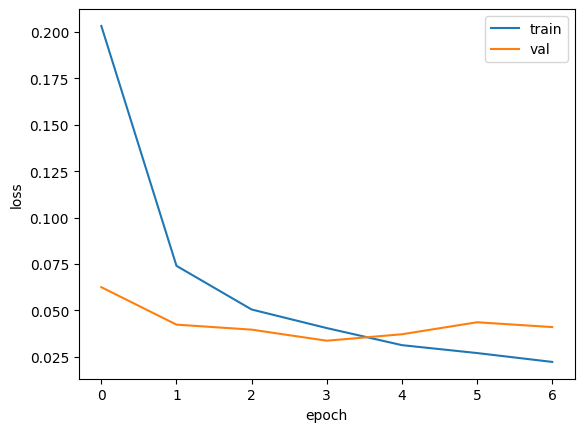

In [104]:
import matplotlib.pyplot as plt

plt.plot(train_hist, label='train')
plt.plot(val_hist, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [105]:
model.load_state_dict(torch.load('best_model3.pt', weights_only=True)) # 모델 로드

<All keys matched successfully>

In [114]:
model.eval() # PyTorch에서 모델을 검증(Validation) 및 추론(Inference) 모드로 전환하는 메서드
corrects = 0
with torch.no_grad(): # PyTorch에서 자동 미분(Autograd) 엔진을 비활성화, Gradient)를 계산하지 않음
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        predicts = torch.argmax(outputs, 1)
        corrects += (predicts == targets).sum().item() # 일치하는 데이터 카운트

accuracy = corrects / len(test_dataset) # 정확도 계산
print(f"검증 정확도: {accuracy:.4f}")

검증 정확도: 0.9923


In [150]:
import torch.nn as nn

model = nn.Sequential()
model.add_module('conv1', nn.Conv2d(1,32, kernel_size=3, padding='same'))
model.add_module('relu1', nn.ReLU())
model.add_module('pool1', nn.MaxPool2d(2))
model.add_module('conv2', nn.Conv2d(32, 16, kernel_size=3, padding='same'))
model.add_module('relu2', nn.ReLU())
model.add_module('pool2', nn.MaxPool2d(2))
model.add_module('flatten', nn.Flatten()) # 입력층
model.add_module('dense1', nn.Linear(784,100)) # 은닉층
model.add_module('relu3', nn.ReLU())
model.add_module('dropout', nn.Dropout(0.3))
model.add_module('dense2', nn.Linear(100,10)) # 출력층

In [151]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)
model.to(device) # GPU에서 실행 되도록 한다.

device = cuda


Sequential(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dense1): Linear(in_features=784, out_features=100, bias=True)
  (relu3): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (dense2): Linear(in_features=100, out_features=10, bias=True)
)

In [152]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss() # 다중 분류, 이진분류: nn.BCELoss 또는 nn.BCEWithLogitsLoss
optimizer = optim.Adam(model.parameters())

In [153]:
train_hist = [] # 훈련 손실 저장
val_hist = [] # 검증 손실 저장
patience = 3 # 검증 손실이 향상될 때까지 에포크 횟수 설정
best_loss = -1 # 최상의 손실 저장
early_stopping_counter = 0 # 연속적으로 검증 손실이 향상되지 않은 에포크 횟수 저장

epochs = 20
for epoch in range(epochs): # 에포크 반복(학습)
    model.train() # 학습(훈련)
    train_loss = 0 # 손실값 초기화
    for inputs, targets in train_loader: # 1 epoch 실행
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad() # 이전에 계산된 기울기값 초기화하는 함수
        outputs = model(inputs) # 모델에 입력 데이터 전달
        loss = criterion(outputs, targets) # 손실값 계산
        loss.backward() # 각 층의 모델 파라메터에 대한 기울기(그레디언트)를 계산
        optimizer.step() # 손실 파라메터 업데이트 
        train_loss += loss.item()
    
    model.eval() # PyTorch에서 모델을 검증(Validation) 및 추론(Inference) 모드로 전환하는 메서드
    val_loss = 0
    with torch.no_grad(): # PyTorch에서 자동 미분(Autograd) 엔진을 비활성화, Gradient)를 계산하지 않음
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

    train_loss = train_loss / len(train_loader)
    val_loss = val_loss / len(val_loader)
    train_hist.append(train_loss)
    val_hist.append(val_loss)
    print(f"에포크:{epoch+1},", f"훈련 손실:{train_loss:.4f}, 검증 손실:{val_loss:.4f}")

    if best_loss == -1 or val_loss < best_loss:
        best_loss = val_loss
        early_stopping_counter = 0
        torch.save(model.state_dict(), 'best_model4.pt')
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= patience:
            print(f"{epoch+1}번째 에포크에서 조기 종료되었습니다.")
            break

에포크:1, 훈련 손실:0.2813, 검증 손실:0.0736
에포크:2, 훈련 손실:0.0962, 검증 손실:0.0580
에포크:3, 훈련 손실:0.0695, 검증 손실:0.0510
에포크:4, 훈련 손실:0.0574, 검증 손실:0.0401
에포크:5, 훈련 손실:0.0503, 검증 손실:0.0423
에포크:6, 훈련 손실:0.0429, 검증 손실:0.0430
에포크:7, 훈련 손실:0.0375, 검증 손실:0.0395
에포크:8, 훈련 손실:0.0344, 검증 손실:0.0409
에포크:9, 훈련 손실:0.0310, 검증 손실:0.0445
에포크:10, 훈련 손실:0.0266, 검증 손실:0.0435
10번째 에포크에서 조기 종료되었습니다.


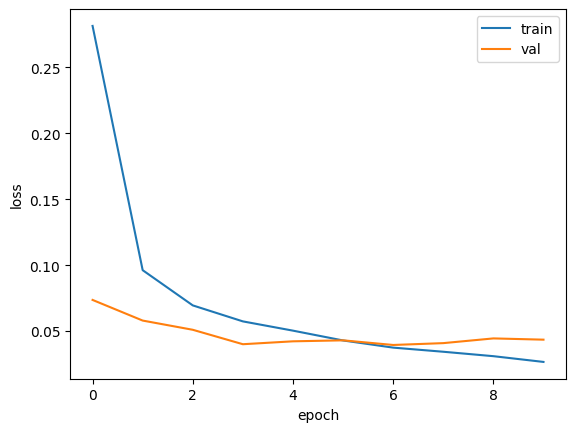

In [154]:
import matplotlib.pyplot as plt

plt.plot(train_hist, label='train')
plt.plot(val_hist, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [155]:
model.load_state_dict(torch.load('best_model4.pt', weights_only=True)) # 모델 로드

<All keys matched successfully>

In [156]:
model.eval() # PyTorch에서 모델을 검증(Validation) 및 추론(Inference) 모드로 전환하는 메서드
corrects = 0
with torch.no_grad(): # PyTorch에서 자동 미분(Autograd) 엔진을 비활성화, Gradient)를 계산하지 않음
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        predicts = torch.argmax(outputs, 1)
        corrects += (predicts == targets).sum().item() # 일치하는 데이터 카운트

accuracy = corrects / len(test_dataset) # 정확도 계산
print(f"검증 정확도: {accuracy:.4f}")

검증 정확도: 0.9879
